# **Modellbővítés (SOLUTION)**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Nyári Diákolimpia, Tábor Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Computer Vision: Solution Notebook</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>40 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2026. június</span>
  </div>
</div>

<br>

> **Figyelem:** ez a notebook a **szervezői/oktatási referencia** változat. Tartalmazza a teljes teszthalmaz valódi címkéit (`test_labels.npy` / `solution.csv`). Ez a versenyzői (RAW) notebookban **nincsen megadva**. A SOLUTION célja, hogy a szervezők kalibrálni tudják a scoring-görbét, és összevethető legyen a contestant-pipeline a referenciával.

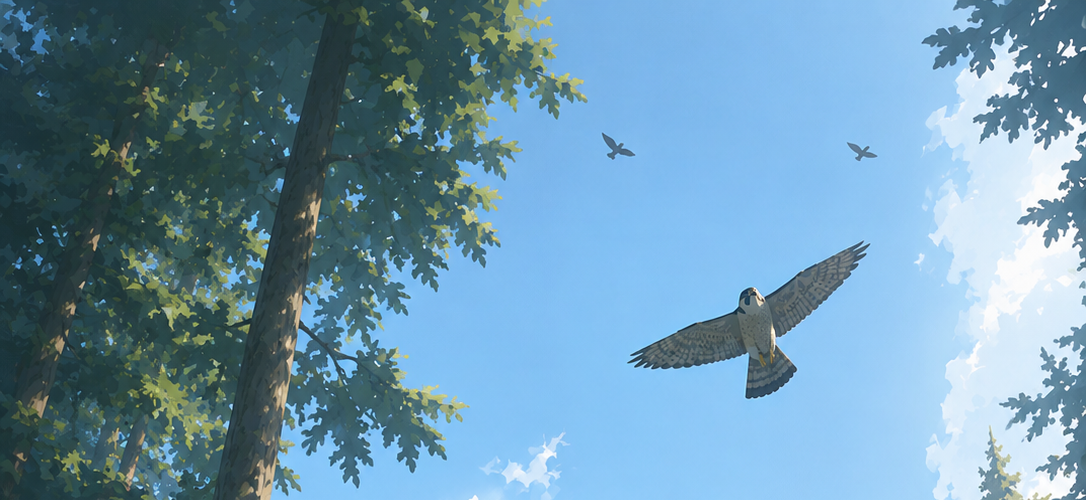

## **Áttekintés**

Gyakori kihívás gépi tanulási modelleknél a felejtés megelőzése. Régi tudást szeretnénk megőrizni, miközben újat sajátítunk el.

A tananyagban szerepel néhány erre alkalmas technika:

1. Paraméterek fagyasztása
2. L2 regularizáció
3. Dropout
4. Korai megállás (early stopping)

Ez a feladat az ilyen és ehhez hasonló technikákról való ismeretét hivatott felmérni a versenyzőknek.

## **Adatok előállítása**

Az adatokat a CUB-200-2011 adathalmazból állítottuk elő.

A versenyzők három adathalmazt kapnak meg (`S0`, `S1` és `S2`), az előtanítás során használt adatokat nem.

**Osztálykiválasztás:** A 200 CUB-osztályból 30-at véletlenszerűen jelöltünk ki alap osztálynak (ezeken tanítjuk elő a modellt). Az `S1` 15 osztályát az előtanított modell feature-terében a prototípus-hasonlóság alapján választottuk: azokat az ismeretlen osztályokat vettük, amelyek koszinusz-hasonlóság szerint legközelebb esnek az alap osztályok átlagos jellemzővektorához - ezek az „nehezebb" osztályok, mert vizuálisan hasonlítanak a már ismertekhez. Az `S2` 10 osztálya véletlenszerűen lett kiválasztva a maradék osztályokból.

**Tanítóhalmazok összeállítása:**

*S1*: osztályonként a 10 legreprezentatívabb képet adtuk meg (azokat, amelyek a feature-térben legközelebb esnek az osztályprototípushoz).

*S2*: osztályonként az 5 legreprezentatívabb kép kap valódi címkét, 20 véletlenszerű képet pedig `UNLABELLED_ID = -100` jelöl.

**Előtanítás:** ResNet18-at (ImageNet-en előtanítva) finomhangoltunk a 30 alap osztályra AdamW optimalizálóval, cosine annealing ütemezővel, korai megállítással (patience=10). 

**Adataugmentáció:** RandomResizedCrop, RandomHorizontalFlip, ColorJitter.

**Teszthalmaz:** Mind az 55 osztályból egyenlő számú képet választottuk véletlenszerűen a CUB eredeti teszthalmazából.

## **Importok**

In [ ]:
import os

import numpy as np
import random
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

def seed_everything(seed=SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Gyorsító: {DEVICE}')

## **Adatok Betöltése**

In [ ]:
DATA_DIR = './baseline_data'
TEST_DATA_DIR = './test_data'

IMG_SIZE = 224
N_BASE_CLASSES = 30
FEATURE_SIZE = 512
UNLABELLED_ID = -100

In [ ]:
import gdown

# Egyenkenti fajlletoltes sajat Drive-azonositoval (a mappaletoltes megbizhatatlan).
BUNDLE_FILES = {
    's0_images.npy':          '1BgL0XARnABgcpPyMYVXQnxMSM3h0BuyZ',
    's0_labels.npy':          '1v8tVweeW9K4Z6Z5Eku1ppQng2BUx9oOY',
    's1_images.npy':          '1XxfAV2rGDWr_ResL2TSvUjV8Jegw4YNH',
    's1_labels.npy':          '1HdQW0cSJs4UEgsZIcXW7D23SO5E0VQZQ',
    's2_images.npy':          '1pgpNXmo3ta_BEZxfvksIDjSB_vpIGqJU',
    's2_labels.npy':          '10wOyQhqT63I8UbYknRGFceHCB6gVtsi8',
    'test_images.npy':        '1_9ImQxOU9WNbwgJ7qG7otDOD6Cwm3FPV',
    'base_model_weights.pth': '1GA-IgBEZxH8h2YwUY1tkoblYPCMv0xOn',
}
# Csak szervezoknek: a teszthalmaz cimkei es az S2 eredeti cimkek.
TEST_FILES = {
    'test_labels.npy':        '1Waq9hS2jLR8mcNLccpkjbeQvAcC3j-Xd',
    's2_labels_original.npy': '1EM7RXPCLF2UivgVXstyDE2EEumU6O9zJ',
}
for target_dir, files in [(DATA_DIR, BUNDLE_FILES), (TEST_DATA_DIR, TEST_FILES)]:
    os.makedirs(target_dir, exist_ok=True)
    for fname, file_id in files.items():
        out = os.path.join(target_dir, fname)
        if os.path.exists(out):
            print(f'{fname} mar letezik, letoltes atugorva.')
        else:
            gdown.download(id=file_id, output=out, quiet=False)

In [ ]:
s0_images = np.load(os.path.join(DATA_DIR, 's0_images.npy'))
s0_labels  = np.load(os.path.join(DATA_DIR, 's0_labels.npy'))
s1_images = np.load(os.path.join(DATA_DIR, 's1_images.npy'))
s1_labels  = np.load(os.path.join(DATA_DIR, 's1_labels.npy'))
s2_images = np.load(os.path.join(DATA_DIR, 's2_images.npy'))
s2_labels  = np.load(os.path.join(DATA_DIR, 's2_labels.npy'))
s2_labels_original  = np.load(os.path.join(TEST_DATA_DIR, 's2_labels_original.npy')) # Ehhez a versenyzők nem férnek hozzá
test_images = np.load(os.path.join(DATA_DIR, 'test_images.npy'))
test_labels = np.load(os.path.join(TEST_DATA_DIR, 'test_labels.npy')) # Ehhez a versenyzők nem férnek hozzá

print(f'Alap osztályok száma : {N_BASE_CLASSES}')
session_images = [s0_images, s1_images, s2_images]
session_labels = [s0_labels, s1_labels, s2_labels]
for s in [0, 1, 2]:
    print()
    print(f'S{s} tanítóhalmaz dimenziói : {session_images[s].shape}')
    print(f'S{s} címkék : {np.unique(session_labels[s])}')
print(f'Teszthalmaz dimenziói : {test_images.shape}')
print(f'Teszthalmaz címkék : {np.unique(test_labels)}')


## **Adathalmaz**

A szervezői verzió tartalmazza az `augment` funkciót, ami a versenyzőknek nem adott, viszont egy elvárt fejlesztés.

In [ ]:
class BirdsDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]
    TRANSFORM = transforms.Compose([
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])
    RANDOM_AUGMENT = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])

    def __init__(self, images, labels, augment=False):
        self.images  = images
        self.labels = labels
        self.transform = self.RANDOM_AUGMENT if augment else self.TRANSFORM
            
    def __len__(self) -> int:
        return len(self.images)
    
    def _get_original_image(self, idx):
        img = self.images[idx]
        _img = img.sum(axis=-1, keepdims=False)
        original_height = _img.sum(axis=1).nonzero()[0].max() + 1
        original_width = _img.sum(axis=0).nonzero()[0].max() + 1
        return img[:original_height, :original_width]

    def __getitem__(self, idx):
        img = Image.fromarray(self._get_original_image(idx)).convert('RGB')
        return self.transform(img), int(self.labels[idx])

## **Előtanított Modell**

A szervezői verzió tartalmazza a `return_features` kényelmi funkciót. Ez alapból nem szerepel a versenyzői notebookban.

In [ ]:
pretrained_weights = torch.load(
    os.path.join(DATA_DIR, "base_model_weights.pth"),
    map_location=torch.device(DEVICE),
    weights_only=False,
)

In [ ]:
class WildlifeVision(nn.Module):
    def __init__(self, num_classes: int = N_BASE_CLASSES, feature_size: int = FEATURE_SIZE):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.head = nn.Linear(feature_size, num_classes)

    def forward(self, x: torch.Tensor, return_features: bool = False) -> torch.Tensor:
        x = self.features(x).flatten(1)  # (B, feature_size)
        if return_features:
            return x
        return self.head(x)


model    = WildlifeVision(num_classes=N_BASE_CLASSES).to(DEVICE)
model.load_state_dict(pretrained_weights, strict=True)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'A modell paramétereinek száma : {n_params:,}')

with torch.no_grad():
    dummy = torch.zeros(16, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    print(f'Próbabemenet dimenziói: {dummy.shape}')
    print(f'A kimenet dimenziói : {model(dummy).shape}')

## **Predikció és Kiértékelés**

In [ ]:
N_S1_NEW_CLASSES = len(np.unique(s1_labels))
N_S2_NEW_CLASSES = len(np.unique(s2_labels)) - 1 # there is an unlabelled id in extra
N_TOTAL_CLASSES = N_BASE_CLASSES + N_S1_NEW_CLASSES + N_S2_NEW_CLASSES

BASE_CLASSES = list(range(N_BASE_CLASSES))
S1_CLASSES = list(range(N_BASE_CLASSES, N_BASE_CLASSES + N_S1_NEW_CLASSES))
S2_CLASSES = list(range(N_BASE_CLASSES + N_S1_NEW_CLASSES, N_BASE_CLASSES + N_S1_NEW_CLASSES + N_S2_NEW_CLASSES))


TASKS = [
    BASE_CLASSES, 
    S1_CLASSES, 
    S2_CLASSES
]

In [ ]:
import pandas as pd

def make_predictions(model, test_images):
    test_data = BirdsDataset(test_images, labels=np.zeros(len(test_images)))
    model.eval()
    predictions = []
    with torch.no_grad():
        for image, _ in test_data:
            image = image.to(DEVICE).unsqueeze(0)
            outputs = model(image)
            preds = outputs.argmax(dim=1).cpu().numpy()
            predictions.extend(preds)
    return np.array(predictions)


def save_predictions(predictions, filename='submission.csv'):
    df = pd.DataFrame({'Id': np.arange(len(predictions)), 'Class': predictions})
    df.to_csv(filename, index=False)


def per_class_accuracy(true_labels, predicted_labels, **kwargs):
    """Returns a dict mapping each class to its accuracy."""
    accs = {}
    for cls in np.unique(true_labels):
        idxs = (true_labels == cls)
        accs[cls.item()] = accuracy_score(true_labels[idxs], predicted_labels[idxs])
    return accs

def per_task_accuracy(true_labels, predicted_labels, tasks, **kwargs):
    """Returns a dict mapping each task to its accuracy."""
    accs = {}
    for i, task in enumerate(tasks):
        idxs = np.nonzero(np.isin(true_labels, task))[0]
        accs[i] = accuracy_score(true_labels[idxs], predicted_labels[idxs])
    return accs

def harmonic_accuracy(true_labels, predicted_labels, tasks):
    per_task_acc = []
    for task in tasks:
        task_indices = np.where(np.isin(true_labels, task))[0]
        task_acc = accuracy_score(true_labels[task_indices], predicted_labels[task_indices])
        per_task_acc.append(task_acc)
    if min(per_task_acc) == 0:
        return 0.0
    return len(per_task_acc) / np.sum(1.0 / np.array(per_task_acc))

def score(true_labels, predicted_labels, tasks, print_details=True):
    H_acc = harmonic_accuracy(true_labels, predicted_labels, tasks)
    f1 = f1_score(true_labels, predicted_labels,
                  labels=list(range(N_TOTAL_CLASSES)), average='macro')
    sc = (H_acc + f1) / 2
    if print_details:
        print(f'Final score: {sc:.4f}')
        print(f'Harmonic Accuracy: {H_acc:.4f}, F1-score: {f1:.4f}')
    return sc, {'H_acc': H_acc, 'f1': f1}

def report(true_labels, predicted_labels, tasks, verbose=2):
    sc = score(true_labels, predicted_labels, tasks, print_details=False)
    pt = per_task_accuracy(true_labels, predicted_labels, tasks)
    pc = per_class_accuracy(true_labels, predicted_labels)
    print('Overall score:', f'{sc[0]:.4f}')
    print('Overall harmonic accuracy:', f'{sc[1]["H_acc"]:.4f}')
    print('Overall F1-score:', f'{sc[1]["f1"]:.4f}')
    print('Min per-class accuracy:', f'{min(pc.values()):.4f}')
    print('Max per-class accuracy:', f'{max(pc.values()):.4f}')
    print('Mean per-class accuracy:', f'{np.mean(list(pc.values())):.4f}')
    print('Std per-class accuracy:', f'{np.std(list(pc.values())):.4f}')
    if verbose >= 1:
        print('\nPer-task accuracy:')
        for task_id, acc in pt.items():
            print(f'  Task {task_id}: {acc:.4f}')
    if verbose >= 2:
        print('\nPer-class accuracy:')
        for cls, acc in pc.items():
            print(f'  Class {cls}: {acc:.4f}')

## **Segédfüggvények**

#### Inicializáció

In [ ]:
def init_model():
    model    = WildlifeVision(num_classes=N_BASE_CLASSES).to(DEVICE)
    model.load_state_dict(pretrained_weights, strict=True)
    return model

#### Paraméter-visszaállítás

Erre a "warm-start" implementálásához van szükség.

In [ ]:
def reinstate_old_params(model, old_head_weight, old_head_bias):
    model.head.weight.data[:N_BASE_CLASSES] = old_head_weight
    model.head.bias.data[:N_BASE_CLASSES] = old_head_bias
    return model

#### Tanítás

In [ ]:
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 32
NUM_EPOCHS = 40
EVAL_EVERY = 2

In [ ]:
def get_dataloader(ds, batch_size=BATCH_SIZE, shuffle=True, seed=SEED):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=torch.Generator().manual_seed(seed))

In [ ]:
def capture_params(model):
    """Snapshot unfrozen parameters for use with l2_anchor_penalty."""
    return {name: param.data.clone().detach()
            for name, param in model.named_parameters()
            if param.requires_grad}


def l2_anchor_penalty(new_model, old_params):
    """L2 penalty on unfrozen parameters relative to old model snapshot.

    old_params : dict returned by capture_params() before training starts
    Returns a scalar; add as: loss = ce_loss + lambda_l2 * l2_anchor_penalty(model, old_params)
    """
    device = next(new_model.parameters()).device
    penalty = torch.tensor(0.0, device=device)
    for name, param in new_model.named_parameters():
        if param.requires_grad and name in old_params:
            penalty = penalty + (param - old_params[name]).pow(2).sum()
    return penalty

In [ ]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: callable,
    device: torch.device,
    old_params=None,
    l2_anchor_lambda=1.0
) -> float:
    """One full pass over the training set. Returns mean loss."""
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        if old_params is not None:
            loss = criterion(model(imgs), labels) + l2_anchor_lambda * l2_anchor_penalty(model, old_params)
        else:
            loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader.dataset)

In [ ]:
def fine_tune(model, train_loader, train_func, num_epochs, 
              hparams={"lr": LR, "weight_decay": WEIGHT_DECAY,
                       "old_params": None,
                       "old_head_weight": None, "old_head_bias": None,
                       "custom_loss": None}, 
              test_images=None, test_labels=None, 
              tasks=None, verbose=2, **kwargs):
    optimizer = torch.optim.Adam(model.parameters(), lr=hparams["lr"], weight_decay=hparams["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    if hparams["custom_loss"] is not None:
        criterion = hparams["custom_loss"]
    else:
        criterion = nn.CrossEntropyLoss()

    scores = []
    best_score = 0.0
    best_model = None

    for epoch in range(1, num_epochs + 1):
        train_loss = train_func(model, train_loader, optimizer, criterion, DEVICE, hparams["old_params"], **kwargs)
        scheduler.step()
        if verbose == 2:
            print(f'Epoch {epoch:02d}, Train loss: {train_loss:.4f}')
        if epoch % EVAL_EVERY == 0 or epoch == num_epochs:
            if test_images is not None and test_labels is not None:
                if hparams["old_head_weight"] is not None and hparams["old_head_bias"] is not None:
                    model = reinstate_old_params(model, hparams["old_head_weight"], hparams["old_head_bias"])
                test_preds = make_predictions(model, test_images)
                sc = score(test_labels, test_preds, tasks=tasks, print_details=(verbose == 2))[0]
                if sc > best_score:
                    best_score = sc
                    best_model = model.state_dict()
                scores.append(sc)
                if tasks is not None:
                    if verbose >= 1:
                        per_task_acc = per_task_accuracy(test_labels, test_preds, tasks=tasks)
                        print(f'Per-task accuracy: {per_task_acc}')
                print()

    if test_images is not None and test_labels is not None:
        print(f'Best score: {max(scores):.4f} at epoch {np.argmax(scores) + 1}')
        # Return the best model, if available
        model.load_state_dict(best_model)
    return model, scores

### Prototípus vektorok

In [ ]:
def get_prototype(model, imgs):
    '''Returns the normalized prototype vector (mean embedding) for a given set of images.'''
    ds = BirdsDataset(imgs, labels=np.zeros(len(imgs)))
    embeddings = []
    for img, _ in ds:
        with torch.no_grad():
            emb = model(img.unsqueeze(0).to(DEVICE), return_features=True).cpu().numpy()
        embeddings.append(emb)
    proto = np.stack(embeddings).mean(axis=0)
    return proto / np.linalg.norm(proto)

def get_class_prototypes(model, images, labels):
    prototypes = []
    for cls in np.unique(labels):
        proto = get_prototype(model, images[labels == cls])
        prototypes.append(proto)
    prototypes = np.stack(prototypes).squeeze()
    return prototypes

def get_nearest_prototype_predictor(model, prototypes, bias=None):
    '''Returns the model with a new head initialized with the given prototypes.'''
    model.head = nn.Linear(512, len(prototypes)).to(DEVICE)
    model.head.weight.data = torch.tensor(prototypes, dtype=torch.float32).to(DEVICE)
    if bias is not None:
        model.head.bias.data = torch.tensor(bias, dtype=torch.float32).to(DEVICE)
    else:
        model.head.bias.data.zero_()
    return model

## **Megoldási Stratégiák**

### Baseline

In [ ]:
model = init_model()
preds = make_predictions(model, test_images)
report(test_labels, preds, tasks=TASKS, verbose=1)

### Random

In [ ]:
preds = np.random.choice(np.arange(N_TOTAL_CLASSES), size=len(test_images))
report(test_labels, preds, tasks=TASKS, verbose=1)

### Feature Prototypes

A legközelebbi prototípusvektor alapján osztályozunk (csak a címkézett képeket felhasználva).

In [ ]:
model = init_model()
s2_labelled_mask = s2_labels != UNLABELLED_ID
all_images = np.concatenate([s0_images, s1_images, s2_images[s2_labelled_mask]])
all_labels = np.concatenate([s0_labels, s1_labels, s2_labels[s2_labelled_mask]])
prototypes = get_class_prototypes(model, all_images, all_labels)
proto_predictior = get_nearest_prototype_predictor(model, prototypes)
preds = make_predictions(proto_predictior, test_images)
report(test_labels, preds, TASKS, verbose=1)

In [ ]:
print("A két legkülönbözőbb osztály koszinusz-hasonlósága: ", (prototypes @ prototypes.T).min())

Látható, hogy az egyes osztályok prototípusai túl hasonlóak, így nem tudjuk felhasználni ezeket klasszifikációhoz. Az adathalmaz "fine-grained", azaz az osztályközi különbségek kicsik, tehát ez várható.

### Mixture of Experts

A beágyazásvektorok felhasználásával osztályozni tudjuk a képeket aszerint, hogy melyik adathalmazba tartozhatnak. Minden adathalmazra tanítunk egy expert modellt, majd ezeket kombinálva állítjuk össze a végső predikciót.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from copy import deepcopy

model = init_model()
relay = SVC()
relay_train_images = np.concatenate([s0_images, s1_images, s2_images])
relay_train_labels = np.concatenate([[0] * len(s0_images), [1] * len(s1_images), [2] * len(s2_images)])
relay_train_ds = BirdsDataset(relay_train_images, relay_train_labels)

with torch.no_grad():
    model.eval()
    relay_train_emb = np.array([model(relay_train_ds[i][0].unsqueeze(0).to(DEVICE), return_features=True).cpu().numpy()
                             for i in range(len(relay_train_ds))])
    relay_train_emb = relay_train_emb.squeeze()

relay.fit(relay_train_emb, relay_train_labels)

relay_test_labels = deepcopy(test_labels)
relay_test_labels[np.isin(test_labels, BASE_CLASSES)] = 0
relay_test_labels[np.isin(test_labels, S1_CLASSES)] = 1
relay_test_labels[np.isin(test_labels, S2_CLASSES)] = 2
test_ds = BirdsDataset(test_images, relay_test_labels)
with torch.no_grad():
    model.eval()
    test_im_embs = np.array([model(test_ds[i][0].unsqueeze(0).to(DEVICE), return_features=True).cpu().numpy()
                                for i in range(len(test_ds))])
    test_im_embs = test_im_embs.squeeze()
s_preds = relay.predict(test_im_embs)
print("Relay pontossága: ", accuracy_score(relay_test_labels, s_preds))
print("Relay F1-score-ja: ", f1_score(relay_test_labels, s_preds, average='macro'))
print("Relay confusion matrix: ", confusion_matrix(relay_test_labels, s_preds))

In [ ]:
s0_expert = init_model()

In [ ]:
s1_expert = init_model()
for param in s1_expert.parameters():
    param.requires_grad = False
s1_expert.head = nn.Linear(512, N_S1_NEW_CLASSES).to(DEVICE)

s1_ds = BirdsDataset(s1_images, s1_labels - N_BASE_CLASSES)
s1_loader = get_dataloader(s1_ds)

s1_expert, _ = fine_tune(
    s1_expert,
    s1_loader,
    train_epoch, 
    20, 
    hparams={"lr": LR, "weight_decay": WEIGHT_DECAY,
             "old_params": None,
            "old_head_weight": None, 
            "old_head_bias": None,
            "custom_loss": None},
    test_images=None, 
    test_labels=None, 
    tasks=[S1_CLASSES],
    verbose=2,
)

In [ ]:
s2_expert = init_model()
for param in s2_expert.parameters():
    param.requires_grad = False
s2_expert.head = nn.Linear(512, N_S2_NEW_CLASSES).to(DEVICE)

s2_labelled_mask = s2_labels != UNLABELLED_ID
s2_ds = BirdsDataset(s2_images[s2_labelled_mask], s2_labels[s2_labelled_mask] - (N_BASE_CLASSES + N_S1_NEW_CLASSES))
s2_loader = get_dataloader(s2_ds)

s2_expert, _ = fine_tune(
    s2_expert,
    s2_loader,
    train_epoch, 
    20, 
    hparams={"lr": LR, "weight_decay": WEIGHT_DECAY,
             "old_params": None,
            "old_head_weight": None, 
            "old_head_bias": None,
            "custom_loss": None},
    test_images=None, 
    test_labels=None, 
    tasks=[S2_CLASSES],
    verbose=2,
)

In [ ]:
preds = np.zeros(len(test_images), dtype=int)
s0_preds = make_predictions(s0_expert, test_images[s_preds == 0])
s1_preds = make_predictions(s1_expert, test_images[s_preds == 1])
s2_preds = make_predictions(s2_expert, test_images[s_preds == 2])
preds[s_preds == 0] = s0_preds
preds[s_preds == 1] = s1_preds + N_BASE_CLASSES
preds[s_preds == 2] = s2_preds + N_BASE_CLASSES + N_S1_NEW_CLASSES

report(test_labels, preds, tasks=TASKS, verbose=1)

### Fine-Tuning

Ha kellően óvatosak vagyunk, akkor finomhangolhatjuk a modellt úgy, hogy az alap osztályokon minimális legyen a teljesítmény-degradáció, és közben javítjuk az új osztályok teljesítményét.

Az alapvető mód, hogy megelőzzük a felejtést, hogy S0 képeit is a tanítóhalmazba keverjük. Lefagyaszthatnánk az egész modellt az utolsó réteg kivételével, ugyanakkor az S1 osztályai szándékosan nehezek, így várhatóan könnyebb lesz őket szeparálni, ha a backbone-t is (vagy legalább néhány rétegét) tanítjuk. Vigyáznunk kell viszont, hogy ne tanítsuk át túlságosan, ezért alkalmazzunk L2 regularizációt, ami bünteti a backbone eredeti paramétereitől való eltérést. Továbbá a legjobb alap-osztály teljesítmény érdekében a fej lecserélésekor visszaállítjuk az osztályokhoz tartozó súlyokat.

Az S2 halmaz 80%-a címkézetlen, ezért várható, hogy pszeudocímkézéssel jelentősen tudjuk javítani a teljesítményt, még akkor is, ha néhány címke hibás. Ezt a címkézést egy expert modellel el tudjuk végezni.

Az utolsó dolgok, amikre figyelni érdemes, hogy viszonylag kicsi learning rate-et használjunk, és megfelelően balanszírozzuk az egyes osztályok példáinak gyakoriságát. Az alap-osztályok képei például kisebbségben vannak, ezért segíthet, ha ezeket többször mutatjuk meg a modellnek (upsampling), esetleg augmentálva az adatot.


> **Megjegyzés (szervezői):** a `fine_tune` minden ellenőrzési ponton a *rejtett teszthalmazon* méri a pontszámot, és a legjobb epoch modelljét tartja meg. Ez szervezői orákulum (a versenyző nem fér hozzá a teszt címkékhez), ezért az itt látott finomhangolt pontszámok **felső korlátot** jelentenek; a valós, no-peek stratégiák (pl. MoE) ~0.49 körül vannak.

#### S2 pszeudo-címkék

In [ ]:
s2_expert = init_model()
for param in s2_expert.parameters():
    param.requires_grad = False
s2_expert.head = nn.Linear(512, N_S2_NEW_CLASSES).to(DEVICE)

s2_labelled_mask = s2_labels != UNLABELLED_ID
s2_ds = BirdsDataset(s2_images[s2_labelled_mask], s2_labels[s2_labelled_mask] - (N_BASE_CLASSES + N_S1_NEW_CLASSES))
s2_loader = get_dataloader(s2_ds)

s2_expert, _ = fine_tune(
    s2_expert,
    s2_loader,
    train_epoch, 
    20, 
    hparams={"lr": LR, "weight_decay": WEIGHT_DECAY,
             "old_params": None,
            "old_head_weight": None, 
            "old_head_bias": None,
            "custom_loss": None},
    test_images=None, 
    test_labels=None, 
    tasks=[S2_CLASSES],
    verbose=2,
)

s2_unlabelled_mask = s2_labels == UNLABELLED_ID
s2_pseudo_labels = make_predictions(s2_expert, s2_images[s2_unlabelled_mask])
s2_pseudo_labels += N_BASE_CLASSES + N_S1_NEW_CLASSES
s2_final_labels = s2_labels.copy()
s2_final_labels[s2_unlabelled_mask] = s2_pseudo_labels

print("Pszeudocímkék megállapításának pontossága: ", accuracy_score(s2_labels_original[s2_unlabelled_mask], s2_final_labels[s2_unlabelled_mask]))
print("Címkék összpontossága: ", accuracy_score(s2_labels_original, s2_final_labels))

#### L2-Anchor nélkül

In [ ]:
# Freeze all parameters except in the last two layers of the backbone
model = init_model()
for param in model.parameters():
    param.requires_grad = False
for param in model.features[7].parameters():
    param.requires_grad = True
for param in model.features[8].parameters():
    param.requires_grad = True
# Extend head with new classes
old_head_weight = model.head.weight.data.clone()
old_head_bias = model.head.bias.data.clone()
model.head = nn.Linear(FEATURE_SIZE, N_TOTAL_CLASSES).to(DEVICE)
model = reinstate_old_params(model, old_head_weight, old_head_bias)

# Use all data
sampling_coeffs = [5, 2, 1]
train_ds = BirdsDataset(np.concatenate([list(s0_images) * sampling_coeffs[0], list(s1_images) * sampling_coeffs[1], list(s2_images) * sampling_coeffs[2]]), 
                        np.concatenate([list(s0_labels) * sampling_coeffs[0], list(s1_labels) * sampling_coeffs[1], list(s2_final_labels) * sampling_coeffs[2]]))

train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)



model, _ = fine_tune(
    model,
    train_loader, 
    train_epoch, 
    NUM_EPOCHS, 
    hparams={"lr": LR, "weight_decay": 0,
             "old_params": None,
            "old_head_weight": None, 
            "old_head_bias": None,
            "custom_loss": None},
    test_images=test_images, 
    test_labels=test_labels, 
    tasks=TASKS, 
    verbose=2
)

preds = make_predictions(model, test_images)
report(test_labels, preds, tasks=TASKS, verbose=1)

#### L2 Anchor

In [ ]:
# Freeze all parameters except in the last two layers of the backbone
model = init_model()
for param in model.parameters():
    param.requires_grad = False
for param in model.features[7].parameters():
    param.requires_grad = True
for param in model.features[8].parameters():
    param.requires_grad = True
unfrozen_params = capture_params(model).copy()
# Extend head with new classes
old_head_weight = model.head.weight.data.clone()
old_head_bias = model.head.bias.data.clone()
model.head = nn.Linear(FEATURE_SIZE, N_TOTAL_CLASSES).to(DEVICE)
model = reinstate_old_params(model, old_head_weight, old_head_bias)

# Use all data
sampling_coeffs = [5, 2, 1]
train_ds = BirdsDataset(np.concatenate([list(s0_images) * sampling_coeffs[0], list(s1_images) * sampling_coeffs[1], list(s2_images) * sampling_coeffs[2]]), 
                        np.concatenate([list(s0_labels) * sampling_coeffs[0], list(s1_labels) * sampling_coeffs[1], list(s2_final_labels) * sampling_coeffs[2]]))

train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

model, _ = fine_tune(
    model,
    train_loader, 
    train_epoch, 
    NUM_EPOCHS, 
    hparams={"lr": LR, "weight_decay": 0,
             "old_params": unfrozen_params,
            "old_head_weight": None, 
            "old_head_bias": None,
            "custom_loss": None},
    test_images=test_images, 
    test_labels=test_labels, 
    tasks=TASKS, 
    verbose=2,
)

preds = make_predictions(model, test_images)
report(test_labels, preds, tasks=TASKS, verbose=1)

#### Pszeudo-címkék nélkül

Hogyan hat a teljesítményre, ha nem használjuk fel a (kicsit zajos) pszeudocímkéket?

In [ ]:
# Freeze all parameters except in the last two layers of the backbone
model = init_model()
for param in model.parameters():
    param.requires_grad = False
for param in model.features[7].parameters():
    param.requires_grad = True
for param in model.features[8].parameters():
    param.requires_grad = True
unfrozen_params = capture_params(model).copy()
# Extend head with new classes
old_head_weight = model.head.weight.data.clone()
old_head_bias = model.head.bias.data.clone()
model.head = nn.Linear(FEATURE_SIZE, N_TOTAL_CLASSES).to(DEVICE)
model = reinstate_old_params(model, old_head_weight, old_head_bias)

# Use all data
sampling_coeffs = [2, 1, 2]
train_ds = BirdsDataset(np.concatenate([list(s0_images) * sampling_coeffs[0], list(s1_images) * sampling_coeffs[1], list(s2_images[s2_labelled_mask]) * sampling_coeffs[2]]), 
                        np.concatenate([list(s0_labels) * sampling_coeffs[0], list(s1_labels) * sampling_coeffs[1], list(s2_labels[s2_labelled_mask]) * sampling_coeffs[2]]))

train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)


model, _ = fine_tune(
    model,
    train_loader, 
    train_epoch, 
    NUM_EPOCHS, 
    hparams={"lr": LR, "weight_decay": 0,
             "old_params": unfrozen_params,
            "old_head_weight": None, 
            "old_head_bias": None,
            "custom_loss": None},
    test_images=test_images, 
    test_labels=test_labels, 
    tasks=TASKS, 
    verbose=2,
)

preds = make_predictions(model, test_images)
report(test_labels, preds, tasks=TASKS, verbose=1)

### MoE és FT kombinációja

Ha egy versenyző sejti, hogy az eredeti modell beágyazásai alapján tanított SVC nem eléggé pontos, így gyakran rossz expertnek küldi a képeket, akkor kombinálhatja a két megközelítést, és egy finomhangolt modellnek a beágyazásait felhasználva egy jobb relay-t taníthat.

Hasonlóképpen lehetséges, hogy egy versenyző a leadeboard pontok alapján meghatározza, hogy melyik betanított modell melyik feladatra "specializálódott", és az adott feladatban az adott modell predikcióját fogadja el, valamilyen prioritási sorrendet felállítva. Ez egyfajta ensemble vagy MoE megközelítés, ami tovább javíthat a teljesítményen.

## **Tanulságok**